> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

# Fourier Coefficient Extraction — Surface Temperature Preprocessing

Before the 2D axisymmetric PINN can enforce a smooth far-field boundary condition at $r = r_\text{max}$, it needs an analytical representation of the undisturbed soil temperature — one that can be evaluated at any $(z, t)$ without storing the raw discrete data. This notebook produces that representation.

The RAD Sol 511 surface temperature data is a real, noisy, discretely-sampled diurnal signal. We decompose it into its Fourier series:

$$T_\text{surface}(t) \approx T_\text{mean} + \sum_{n=1}^{N} A_n \cos(n \omega t + \phi_n)$$

where $\omega = 2\pi / t_\text{sol}$ is the fundamental diurnal frequency. Each harmonic $n$ captures a progressively finer feature of the diurnal cycle — the first captures the broad day/night swing, higher harmonics capture the sharper peak around noon and the asymmetry between warming and cooling.

The fitted coefficients $A_n$, $\phi_n$, $T_\text{mean}$, $\omega$, and $N_\text{harmonics}$ are saved to `fourier_coefficients.pkl`. This file is then loaded by the 2D PINN notebooks to reconstruct a smooth, differentiable surface signal at any point in time — without needing to carry the raw Excel data into the physics loop.

/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


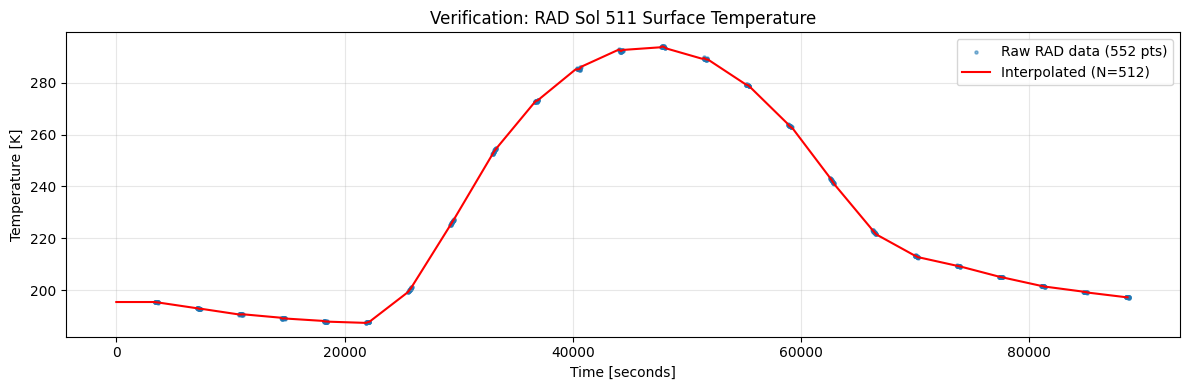

In [1]:
# ============================================
# CELL 1: Load RAD data + interpolate to uniform grid
# ============================================

from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)

n_points = 20000

# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)
wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# --- Choose a uniform grid ---

N_uniform = 512
t_uniform = jnp.linspace(0, sol_seconds, N_uniform, endpoint=False)

# ---Interpolate ---

T_uniform = np.interp(t_uniform, ltst_surf, temp_surf)

# --- Verify with a plot ---
# --- Verify with a plot ---
plt.figure(figsize=(12, 4))
plt.scatter(ltst_surf, temp_surf, s=5, alpha=0.5, label='Raw RAD data (552 pts)')
plt.plot(t_uniform, T_uniform, 'r-', linewidth=1.5, label=f'Interpolated (N={N_uniform})')
plt.xlabel('Time [seconds]')
plt.ylabel('Temperature [K]')
plt.title('Verification: RAD Sol 511 Surface Temperature')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


T_mean from FFT: 228.69 K
T_mean expected:  225.60 K
First 5 amplitudes: [50.1714    18.868832   1.8388853  3.6909747  0.9149043]
Diurnal amplitude (A_1): 50.17 K


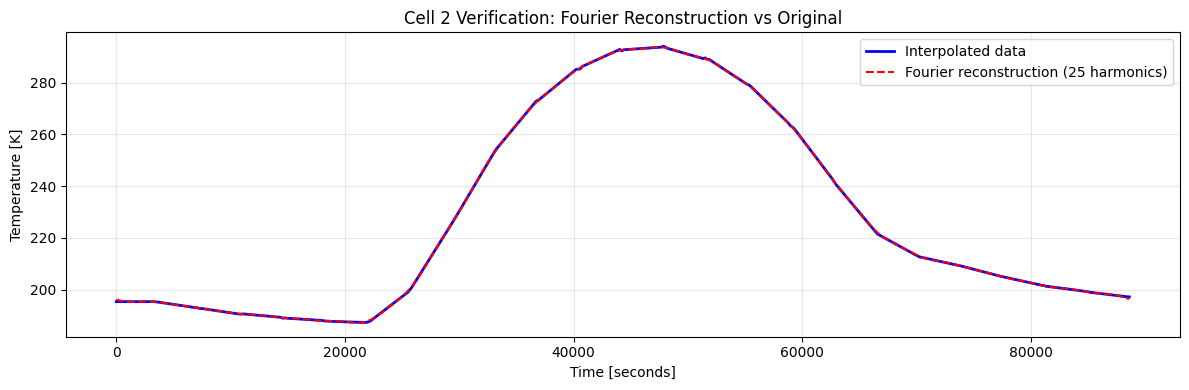

Max reconstruction error: 0.8229 K


In [3]:
# ============================================
# CELL 2: FFT decomposition of surface temperature
# ============================================

# --- Compute FFT ---
N = N_uniform
fft_coeffs = jnp.fft.rfft(T_uniform)

# --- Step B: Extract mean, amplitudes, phases ---
T_mean_fft = jnp.real(fft_coeffs[0] / N)          # from c[0] — should be ~225.6 K
# T_mean_ft = avg_bottom_temp
# T_mean_fft = T_mean_ft * jnp.ones_like(t_uniform)
A_n = 2 * jnp.abs(fft_coeffs) / N
phi_n = jnp.angle(fft_coeffs)
N_harmonics = 25          # how many to keep

print(f"T_mean from FFT: {T_mean_fft:.2f} K")
print(f"T_mean expected:  {avg_bottom_temp:.2f} K")
print(f"First 5 amplitudes: {A_n[1:6]}")
print(f"Diurnal amplitude (A_1): {A_n[1]:.2f} K")

# --- : Reconstruct and verify -
omega = 2 * jnp.pi / sol_seconds
n_vals = jnp.arange(1, N_harmonics + 1)    # shape (15,)

# Build the argument of the cosine

t_col = t_uniform.reshape(-1, 1)               # (512, 1)
angles = n_vals * omega * t_col + phi_n[1:N_harmonics+1]  # (512, 15). Skips index 0 and grabs harmonics 1 to 15

# multiply by amplitudes and take cosine
harmonics_matrix = A_n[1:N_harmonics+1] * jnp.cos(angles)  # (512, 15)

# Ssum across columns (axis=1) to get one value per time point
T_reconstructed = T_mean_fft + jnp.sum(harmonics_matrix, axis=1)  # (512,)


# --- Plot original vs reconstruction ---

plt.figure(figsize=(12, 4))
plt.plot(t_uniform, T_uniform, 'b-', linewidth=2, label='Interpolated data')
plt.plot(t_uniform, T_reconstructed, 'r--', linewidth=1.5, label=f'Fourier reconstruction ({N_harmonics} harmonics)')
plt.xlabel('Time [seconds]')
plt.ylabel('Temperature [K]')
plt.title('Cell 2 Verification: Fourier Reconstruction vs Original')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max reconstruction error: {jnp.max(jnp.abs(T_uniform - T_reconstructed)):.4f} K")

In [4]:
# ============================================
# CELL 3: Analytical T(z, t) — pure JAX
# ============================================


def make_analytical_solution(A_n, phi_n, T_mean, N_harmonics, omega):
    """
    Returns a pure JAX function T(t, z) -> temperature.

    Why a closure? The Fourier coefficients are baked in at
    creation time, so the returned function only takes (t, z).
    """
    # Pre-compute skin depths for harmonics 1..N_harmonics
    n_vals = jnp.arange(1, N_harmonics + 1)

    # Slice the coefficients we need (harmonics 1 to N_harmonics)
    An = A_n[1:N_harmonics + 1]
    phin = phi_n[1:N_harmonics + 1]

    @jit
    def T_analytical(t, z, kappa):
        """
        Compute temperature at given (t, z).
        t: time in seconds, z: depth in meters
        Both can be scalars or arrays.
        """

        delta_n = jnp.sqrt(2 * kappa / (n_vals * omega) )  # skin depth for each harmonic

        return T_mean + jnp.sum(An * jnp.exp(-z / delta_n) * jnp.cos(n_vals * omega * t - z / delta_n + phin))

    return T_analytical


# Scalar version — your function
T_sol = make_analytical_solution(A_n, phi_n, T_mean_fft, N_harmonics, omega)

# Batched version — JAX handles the vectorization
T_sol_batch = vmap(T_sol, in_axes=(0, 0, None))  # map over axis 0 of both t and z

In [5]:
# Create the analytical solution
T_sol = make_analytical_solution(A_n, phi_n, T_mean_fft, N_harmonics, omega)
T_sol_batch = vmap(T_sol, in_axes=(0, 0, None))

learned_kappa = 3.93e-8

# Test 1: Does T(t, z=0) match the surface data?
T_surface_check = T_sol_batch(t_uniform, jnp.zeros_like(t_uniform), learned_kappa)
print(f"Surface max error: {jnp.max(jnp.abs(T_surface_check - T_reconstructed)):.6f} K")

# Test 2: Does T(t, z=0.4) ≈ T_mean for all times?
T_deep_check = T_sol_batch(t_uniform, 0.4 * jnp.ones_like(t_uniform), learned_kappa)
print(f"Deep temp range: {jnp.min(T_deep_check):.4f} to {jnp.max(T_deep_check):.4f} K")
print(f"Deep temp mean:  {jnp.mean(T_deep_check):.4f} K (expected ~{float(T_mean_fft):.2f})")

Surface max error: 0.000000 K
Deep temp range: 228.6886 to 228.6892 K
Deep temp mean:  228.6889 K (expected ~228.69)


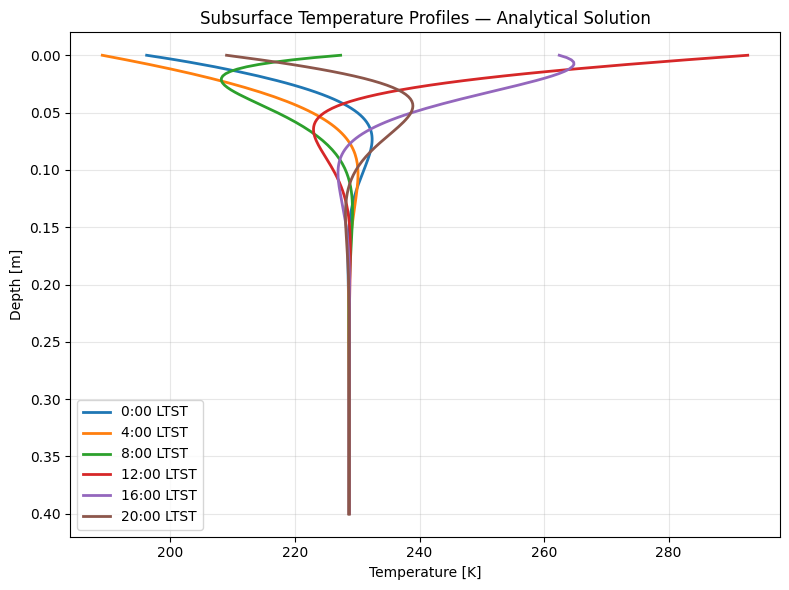

Diurnal skin depth δ₁ = 3.33 cm


In [6]:
# ============================================
# CELL 5: Depth profiles at different times of day
# ============================================

z_plot = jnp.linspace(0, 0.4, 200)

# Pick 6 times spread across the sol (in hours for labels)
hours = [0, 4, 8, 12, 16, 20]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

plt.figure(figsize=(8, 6))
for i, h in enumerate(hours):
    t_sec = h * sol_seconds / 24
    T_profile = T_sol_batch(t_sec * jnp.ones_like(z_plot), z_plot, learned_kappa)
    plt.plot(T_profile, z_plot, color=colors[i], linewidth=2, label=f'{h}:00 LTST')

plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel('Temperature [K]')
plt.ylabel('Depth [m]')
plt.title('Subsurface Temperature Profiles — Analytical Solution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print skin depth for reference
delta_1 = jnp.sqrt(2 * learned_kappa / omega)
print(f"Diurnal skin depth δ₁ = {delta_1*100:.2f} cm")

In [7]:
import pickle

coeffs = {
    'A_n': np.array(A_n),
    'phi_n': np.array(phi_n),
    'T_mean': float(T_mean_fft),
    'N_harmonics': N_harmonics,
    'omega': omega,
}

with open('../../resources/data/fourier_coefficients.pkl', 'wb') as f:
    pickle.dump(coeffs, f)

print("Saved Fourier coefficients")

Saved Fourier coefficients


This code to be copied at the start of the 2D perturbance notebook. Import the stored dourier coefficients

In [ ]:
import pickle

with open('../../resources/data/fourier_coefficients.pkl', 'rb') as f:
    coeffs = pickle.load(f)

T_far = make_analytical_solution(
    jnp.array(coeffs['A_n']),
    jnp.array(coeffs['phi_n']),
    coeffs['T_mean'],
    coeffs['N_harmonics'],
    coeffs['omega']
)

# Now in your 2D PINN loss function:
# T_far(t, z) gives the far-field BC at any (t, z) pair